# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 

## 🔥 Components of the FWI System

The system has six key components, split into two categories:

---

### 🌿 Fuel Moisture Codes  
These estimate how dry the forest floor and organic matter are:

| Code | Description |
|------|-------------|
| **FFMC** (Fine Fuel Moisture Code) | Moisture in litter and fine fuels — affects ignition ease |
| **DMC** (Duff Moisture Code)       | Moisture in moderate-depth organic layers — affects fuel consumption |
| **DC** (Drought Code)              | Moisture in deep, compact organic layers — reflects long-term dryness |

---

### 🔥 Fire Behavior Indices  
These predict how a fire might behave:

| Index | Description |
|-------|-------------|
| **ISI** (Initial Spread Index) | Expected rate of fire spread — based on wind and FFMC |







### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load the libraries as required.

import os
import sys
import pandas as pd
from dotenv import load_dotenv

'''
Load environment file
'''
load_dotenv()

'''
Append SRC DIR to sys.path
'''
sys.path.append(os.getenv("SRC_DIR"))
src_dir = os.getenv("SRC_DIR")

'''
Enable logger
'''
from utils.logger import get_logger
_logs = get_logger(__name__)

_logs.info("Environment variables loaded.")
_logs.info(f"SRC_DIR resolved to: {src_dir}")
_logs.info(f"Current working directory: {os.getcwd()}")

2025-10-05 21:54:46,483, 2237717006.py, 25, INFO, Environment variables loaded.
2025-10-05 21:54:46,484, 2237717006.py, 26, INFO, SRC_DIR resolved to: ../../05_src/
2025-10-05 21:54:46,485, 2237717006.py, 27, INFO, Current working directory: /Users/doren/DSI/module5-production/production/02_activities/assignments


In [2]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
_logs.info("Set list of custom column names.")

fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()

_logs.info("Load dataset, skip and replace header row with custom column names")

2025-10-05 21:54:46,514, 2733999679.py, 5, INFO, Set list of custom column names.
2025-10-05 21:54:46,590, 2733999679.py, 10, INFO, Load dataset, skip and replace header row with custom column names


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


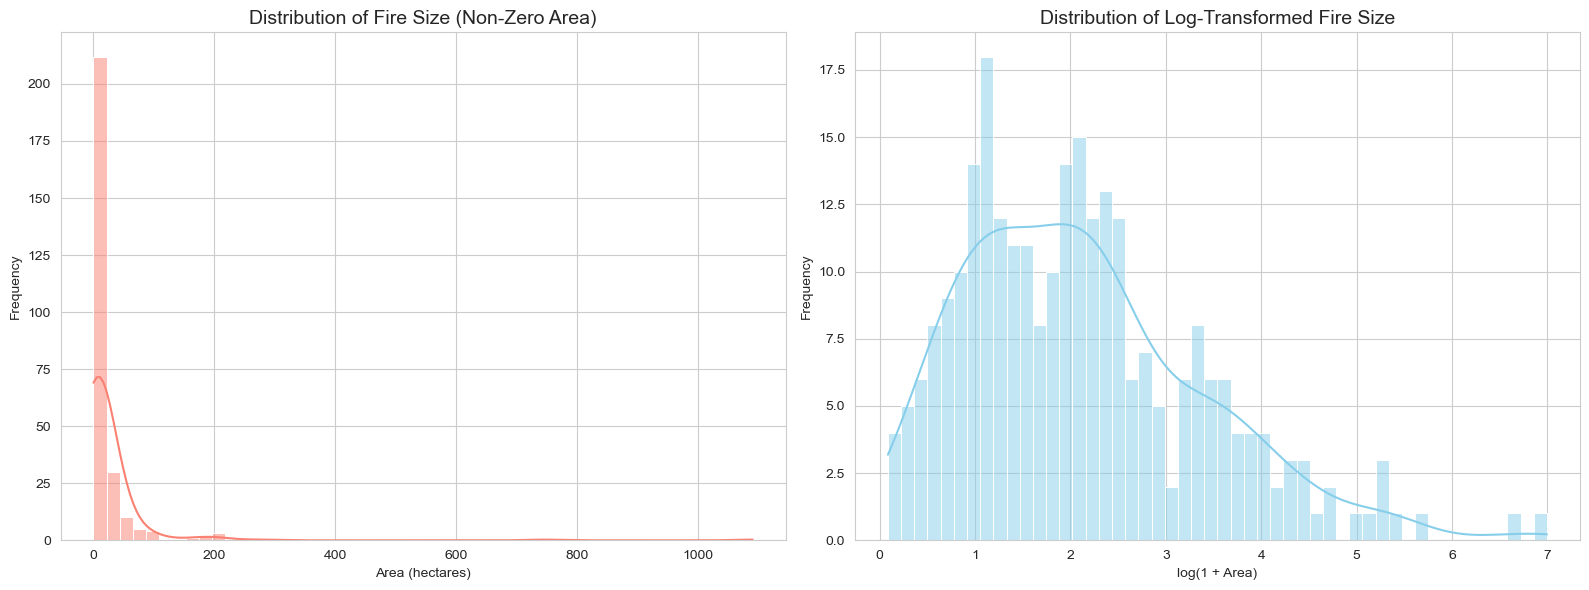

In [3]:
'''
Data visualization before modeling
'''
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

'''
Define feature groupings for visual analysis
'''
numeric_viz_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area']
categorical_viz_features = ['month', 'day']

'''
Create a copy for data visualization
'''
fires_viz = fires_dt.copy()

# Filter out zero-area fires
fires_nonzero = fires_viz[fires_viz['area'] > 0].copy()

# Create log-transformed area
fires_nonzero['log_area'] = np.log1p(fires_nonzero['area'])

# Set plot style
sns.set_style("whitegrid")

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of original area (non-zero only)
sns.histplot(fires_nonzero['area'], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title("Distribution of Fire Size (Non-Zero Area)", fontsize=14)
axes[0].set_xlabel("Area (hectares)")
axes[0].set_ylabel("Frequency")

# Histogram of log-transformed area (non-zero only)
sns.histplot(fires_nonzero['log_area'], bins=50, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title("Distribution of Log-Transformed Fire Size", fontsize=14)
axes[1].set_xlabel("log(1 + Area)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [4]:
zero_pct = (fires_dt['area'] == 0).mean() * 100
print(f"Percentage of zero-area entries: {zero_pct:.2f}%")

Percentage of zero-area entries: 47.78%


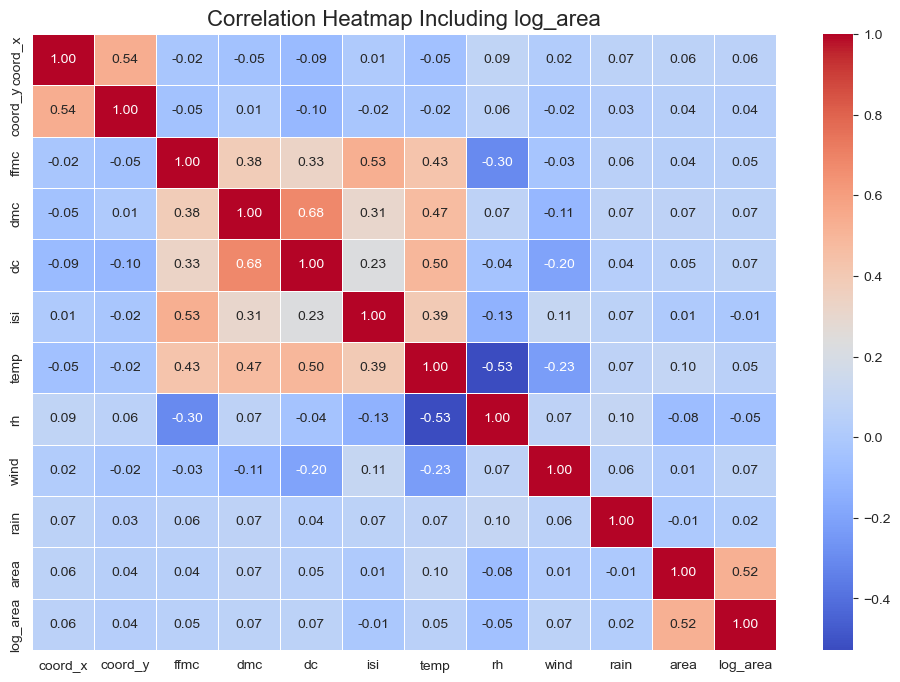

In [5]:
# Create a copy and add log_area
fires_viz = fires_dt.copy()
fires_viz['log_area'] = np.log1p(fires_viz['area'])

# Select numeric features including log_area
numeric_viz_features_with_log_area = fires_viz.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_viz_features_with_log_area.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap Including log_area", fontsize=16)
plt.show()

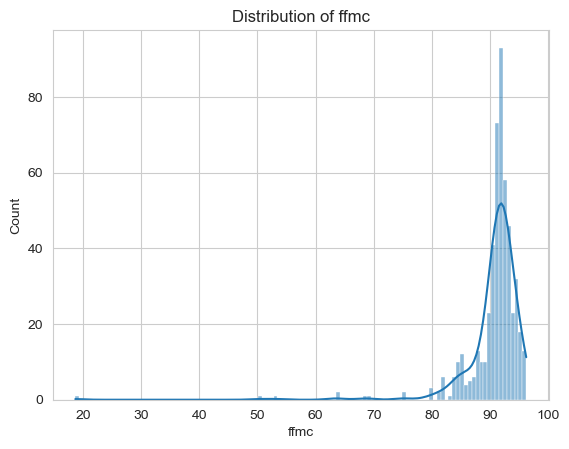

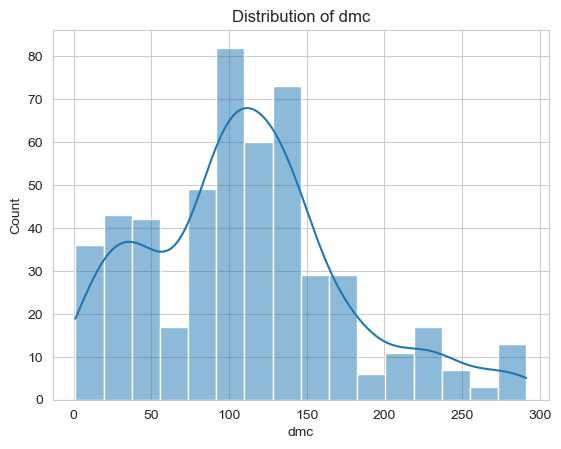

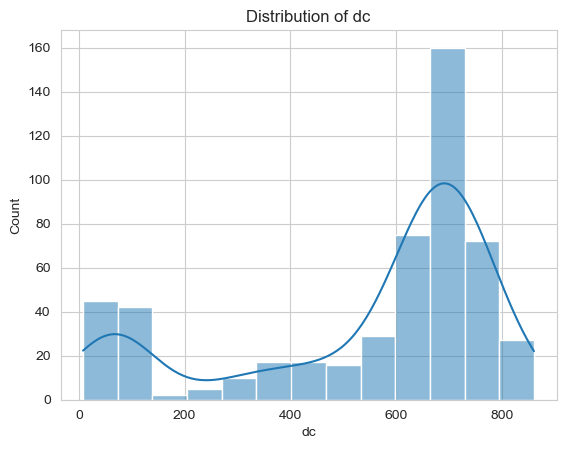

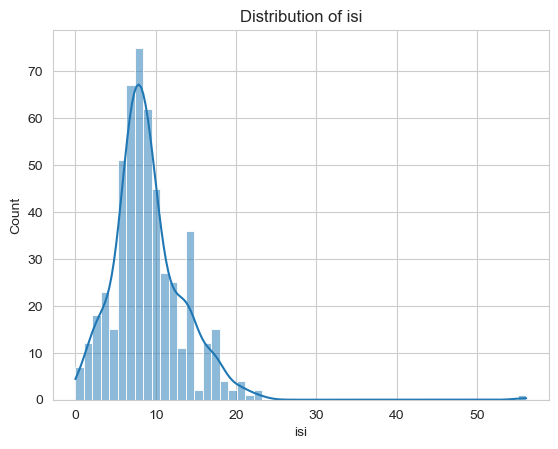

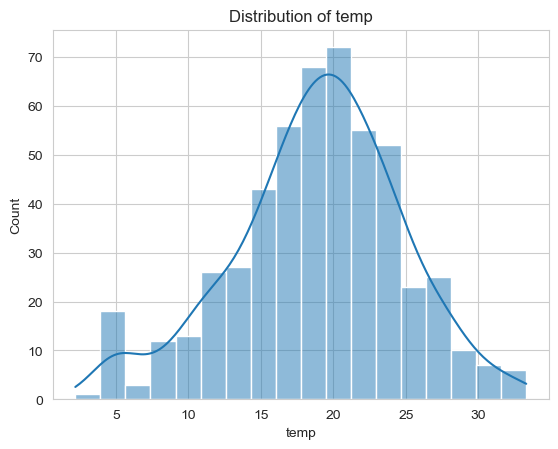

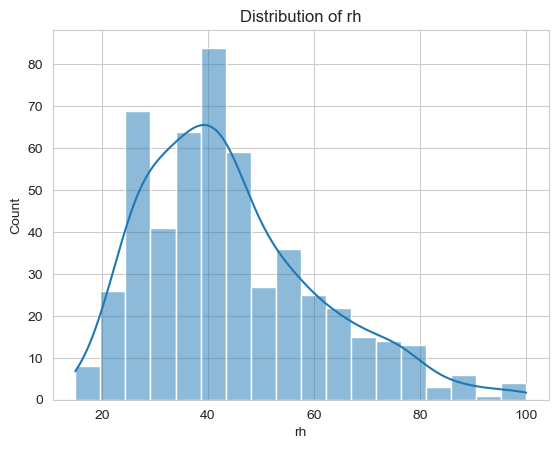

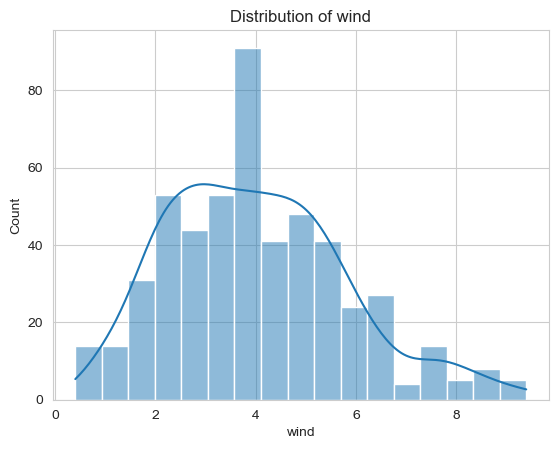

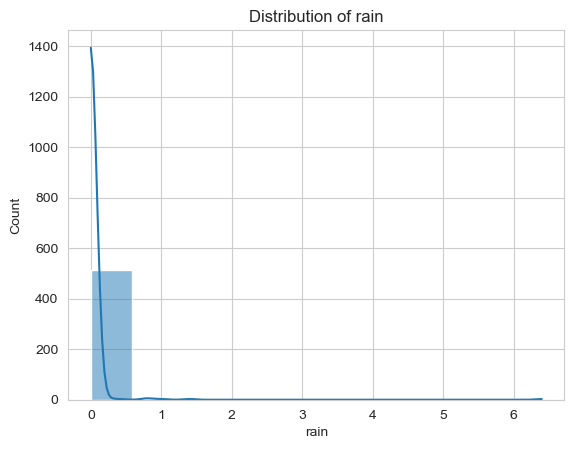

In [6]:
for col in [cols for cols in numeric_viz_features if cols not in ['coord_x', 'coord_y', 'area']]:
    sns.histplot(fires_dt[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Get X and Y

Create the features data frame and target data.

In [7]:
'''
Apply log transformation to area as original area variable is highly skewed 
with 47.78% of the entries being zero
'''
fires_dt['log_area'] = np.log1p(fires_dt['area'])

In [8]:
'''
Check for unexpected values in categorical columns
'''
fires_dt['month'].unique()

array(['mar', 'oct', 'aug', 'sep', 'apr', 'jun', 'jul', 'feb', 'jan',
       'dec', 'may', 'nov'], dtype=object)

In [9]:
'''
Check for unexpected values in categorical columns
'''
fires_dt['day'].unique()

array(['fri', 'tue', 'sat', 'sun', 'mon', 'wed', 'thu'], dtype=object)

In [10]:
'''
Create X: the features data includes all features excluding area
'''
X = fires_dt.drop(columns=['area','log_area'])
X

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB


In [12]:
'''
Create y: target data is area
'''
y = fires_dt['log_area']
y


0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
         ...   
512    2.006871
513    4.012592
514    2.498152
515    0.000000
516    0.000000
Name: log_area, Length: 517, dtype: float64

In [13]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 517 entries, 0 to 516
Series name: log_area
Non-Null Count  Dtype  
--------------  -----  
517 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
'''
Define feature groups
'''
numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']

'''
Future-proof for data is not pristine - impute missing values with statical mean
for numeric_features and with most frequent value for categorical_features
'''
preproc1 = ColumnTransformer(
    transformers=[
        ('num_scaler', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        
        ('cat_enc', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ],
    remainder='passthrough'
)
preproc1

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_scaler',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('cat_enc',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['month', 'day'])])

### Preproc 2

Create preproc2 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [15]:
from sklearn.preprocessing import PowerTransformer

numeric_features_skewed = ['ffmc', 'dmc', 'dc', 'isi', 'rh', 'rain']
numeric_features_unskewed = [col for col in numeric_features if col not in numeric_features_skewed]

preproc2 = ColumnTransformer(
    transformers=[
        ('num_skewed', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('power', PowerTransformer()),
            ('scaler', MinMaxScaler())
        ]), numeric_features_skewed),

        ('num_unskewed', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', MinMaxScaler())
        ]), numeric_features_unskewed),

        ('cat_enc', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features
        )
    ],
    remainder='passthrough'
)

preproc2

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_skewed',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('power', PowerTransformer()),
                                                 ('scaler', MinMaxScaler())]),
                                 ['ffmc', 'dmc', 'dc', 'isi', 'rh', 'rain']),
                                ('num_unskewed',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', MinMaxScaler())]),
                                 ['coord_x', 'coord_y', 'temp', 'wind']),
                                ('cat_enc',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['month', 'day'])])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [16]:
# Pipeline A = preproc1 + baseline

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

'''
Baseline model
'''
baseline_model = Ridge()

'''
Advanced_model: RandomForestRegressor
'''
advanced_model = RandomForestRegressor(random_state=42)

pipeline_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', baseline_model)
])

pipeline_A

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_scaler',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_enc',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['month', 'day'])])),
                ('regressor', Ridge())])

In [17]:
# Pipeline B = preproc2 + baseline

pipeline_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', baseline_model)
])

pipeline_B

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_skewed',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('power',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['ffmc', 'dmc', 'dc', 'isi',
                                                   'rh', 'rain']),
                                                 ('num_unskewed',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['coord_x', 'coord_y', 'temp',
                                                   'wind']),
                                                 ('cat_enc',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['month', 'day'])])),
                ('regressor', Ridge())])

In [18]:
# Pipeline C = preproc1 + advanced model

pipeline_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', advanced_model)
])

pipeline_C

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_scaler',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_enc',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [19]:
# Pipeline D = preproc2 + advanced model

pipeline_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', advanced_model)
])

pipeline_D

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_skewed',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('power',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['ffmc', 'dmc', 'dc', 'isi',
                                                   'rh', 'rain']),
                                                 ('num_unskewed',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['coord_x', 'coord_y', 'temp',
                                                   'wind']),
                                                 ('cat_enc',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [20]:
from sklearn.model_selection import GridSearchCV

'''
GridSearch for pipeline A
'''
param_grid_A = {
    'regressor__alpha' : [0.01, 0.1, 1.0, 10.0]
}

grid_A = GridSearchCV(
    estimator=pipeline_A,
    param_grid=param_grid_A,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

In [21]:
'''
GridSearch for pipeline B
'''
param_grid_B = {
    'regressor__alpha' : [0.01, 0.1, 1.0, 10.0]
}

grid_B = GridSearchCV(
    estimator=pipeline_B,
    param_grid=param_grid_B,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

In [22]:
'''
GridSearch for pipeline C
'''
param_grid_C = {
    'regressor__n_estimators' : [50, 100, 200, 300]
}

grid_C = GridSearchCV(
    estimator=pipeline_C,
    param_grid=param_grid_C,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

In [23]:
'''
GridSearch for pipeline D
'''
param_grid_D = {
    'regressor__max_depth' : [None, 10, 20, 30]
}

grid_D = GridSearchCV(
    estimator=pipeline_D,
    param_grid=param_grid_D,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

In [24]:
from sklearn.model_selection import train_test_split

'''
Split dataset for training and testing
'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, max_error, r2_score

grid_A.fit(X_train, y_train)
grid_B.fit(X_train, y_train)
grid_C.fit(X_train, y_train)
grid_D.fit(X_train, y_train)

def evaluate_pipeline(grid, X_train, X_test, y_train, y_test, label):
    model = grid.best_estimator_
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    return {
        'Pipeline': label,
        'Best Params': grid.best_params_,
        'RMSE Train': root_mean_squared_error(y_train, y_pred_train),
        'RMSE Test': root_mean_squared_error(y_test, y_pred_test),
        'MAE Train': mean_absolute_error(y_train, y_pred_train),
        'MAE Test': mean_absolute_error(y_test, y_pred_test),
        'Max Error Train': max_error(y_train, y_pred_train),
        'Max Error Test': max_error(y_test, y_pred_test),
        'R2 Train': r2_score(y_train, y_pred_train),
        'R2 Test': r2_score(y_test, y_pred_test)
    }

results = [
    evaluate_pipeline(grid_A, X_train, X_test, y_train, y_test, 'Pipeline A'),
    evaluate_pipeline(grid_B, X_train, X_test, y_train, y_test, 'Pipeline B'),
    evaluate_pipeline(grid_C, X_train, X_test, y_train, y_test, 'Pipeline C'),
    evaluate_pipeline(grid_D, X_train, X_test, y_train, y_test, 'Pipeline D')
]

results_df = pd.DataFrame(results)
results_df

,Pipeline,Best Params,RMSE Train,RMSE Test,MAE Train,MAE Test,Max Error Train,Max Error Test,R2 Train,R2 Test
0,Pipeline A,{'regressor__alpha': 10.0},1.332889,1.468580,1.100731,1.183309,5.216969,5.392379,0.059812,0.018715
1,Pipeline B,{'regressor__alpha': 10.0},1.337082,1.464561,1.106610,1.187567,5.335265,5.475984,0.053888,0.024079
2,Pipeline C,{'regressor__n_estimators': 300},0.546184,1.522842,0.439834,1.207687,2.256352,6.120248,0.842128,-0.055138
3,Pipeline D,{'regressor__max_depth': 10},0.711051,1.513050,0.585620,1.204644,2.536266,6.124693,0.732435,-0.041612


# Evaluate

+ Which model has the best performance?

To improve prediction accuracy and reduce the impact of extreme values in the Forest Fires dataset, I applied a log transformation to the target variable area, creating a new feature log_area. This transformation helped normalize the distribution, making it easier for models to learn meaningful patterns and reducing the influence of outliers. The original area variable is highly skewed, with 47.78% of the entries being zero, which makes it difficult for models to generalize effectively.

I evaluated four pipelines using Root Mean Squared Error (RMSE) as the primary error metric. RMSE measures the average magnitude of prediction errors, and lower RMSE scores indicate better model performance. Among the Ridge regression models, Pipeline B achieved the lowest RMSE on the test set (1.4646) and the highest R² score (0.0241), suggesting modest but consistent generalization to unseen data.

Compared to models trained on the original area, those trained on log_area showed significantly lower error metrics and better fit on training data. While more complex models like Random Forests (Pipelines C and D) performed exceptionally well on training data, they exhibited higher test RMSE and negative R² scores, indicating overfitting. Therefore, Pipeline B offers the best balance between accuracy and generalization, making it the most suitable choice for this regression task.

# Export

+ Save the best performing model to a pickle file.

In [26]:
import pickle

# Save the best estimator from grid_B
with open('best_model_pipeline_B.pkl', 'wb') as f:
    pickle.dump(grid_B.best_estimator_, f)

_logs.info("Model saved successfully to 'best_model_pipeline_B.pkl'")


2025-10-05 21:55:37,053, 2928370133.py, 7, INFO, Model saved successfully to 'best_model_pipeline_B.pkl'


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/opt/minic

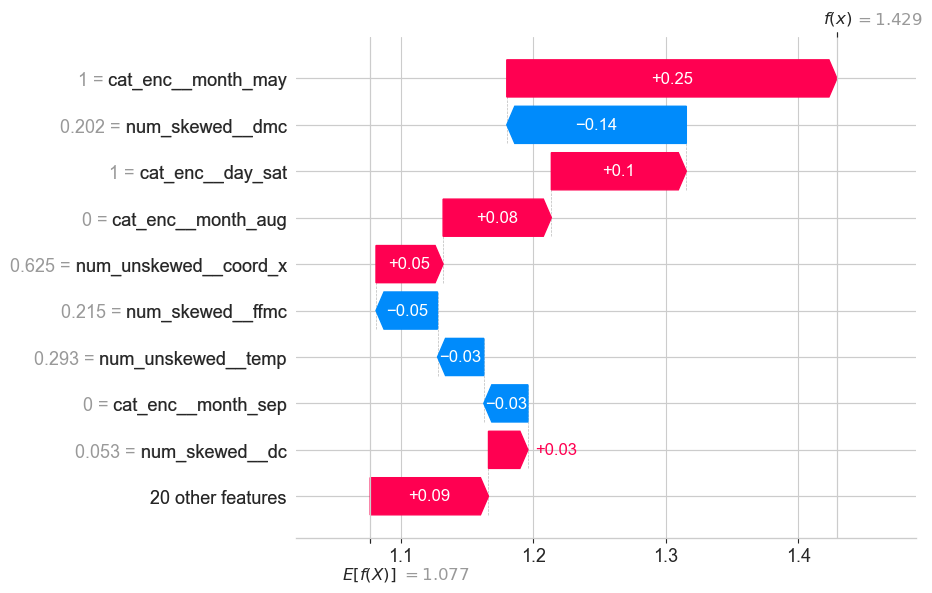

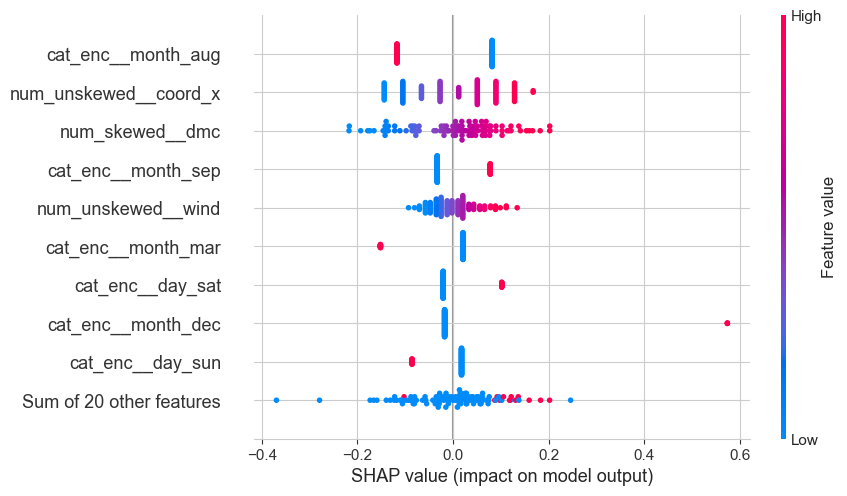

In [27]:
import shap

# Get the best model from GridSearchCV
best_model = grid_B.best_estimator_

# Transform the test set using the pipeline's preprocessing step
X_test_transformed = best_model.named_steps['preprocessing'].transform(X_test)

# Convert to DataFrame for readable feature names
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=best_model.named_steps['preprocessing'].get_feature_names_out()
)

# Access the Ridge regression model
ridge_model = best_model.named_steps['regressor']

# Create SHAP explainer and compute SHAP values
explainer = shap.Explainer(ridge_model.predict, X_test_transformed_df)
shap_values = explainer(X_test_transformed_df)

# Display local explanation (first test observation)
shap.plots.waterfall(shap_values[0])

# Display global explanation
shap.plots.beeswarm(shap_values)


*(Answer here.)*

Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

For observation 0 in the waterfall plot, the model begins with a base value of 1.077 (average log-transformed area) and predicts 1.429, which corresponds to approximately 3.17 hectares burned.

The most influential features were:

1. month_may: Increased the prediction by +0.25
2. dmc: Decreased it by −0.14
3. day_sat: Added +0.10

Other features such as month_aug, ffmc, temp, and dc had smaller effects. Together, these contributions explain why the model predicted a higher-than-average burned area for this fire.

In general, across the complete training set, which features are the most and least important.

Based on the SHAP beeswarm plot for the best-performing model (pipeline_B), here’s a concise summary of the most and least important features across the entire training set:

Most Important Features
These features had the largest SHAP values and widest spread, meaning they consistently influenced predictions across many observations:

1. month_aug: Strong seasonal signal — fires in August often led to higher predicted burned areas.
2. coord_x: Spatial location mattered — certain regions were more prone to larger fires.
3. dmc: A key dryness indicator — higher values often increased predicted area.

Least Important Features
These features showed low SHAP values and minimal spread, suggesting they had little influence on predictions:

1. month_sat
2. month_dec
3. day_sun


If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

Based on the global SHAP beeswarm plot, I would consider removing features that consistently show low importance and minimal impact on predictions. These include:

1. month_sat
2. month_dec
3. day_sun

These features appear near the bottom of the beeswarm plot, with SHAP values close to zero and little spread, indicating they rarely influence the model’s output.

How to Test Their Value?
To evaluate whether these features enhance model performance:
1. Remove them from the dataset.
2. Retrain the model using the same pipeline and hyperparameter tuning.
3. Compare performance metrics (e.g., RMSE, R²) on the test set before and after removal.

If performance remains stable or improves, it suggests these features were not contributing meaningfully and can be safely excluded.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.